In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap


In [4]:
df = pd.read_csv('../../data/processed/bank_data_preprocessed_v2.csv')


In [5]:
display(df)

,age,job,marital,default,housing,loan,month,duration,pdays,deposit,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,59,admin.,married,no,yes,no,may,1042,-1,1,...,False,False,False,False,False,False,True,False,False,False
1,56,admin.,married,no,no,no,may,1467,-1,1,...,False,False,False,False,False,False,True,False,False,False
2,41,technician,married,no,yes,no,may,1389,-1,1,...,False,False,False,False,False,False,True,False,False,False
3,55,services,married,no,yes,no,may,579,-1,1,...,False,False,False,False,False,False,True,False,False,False
4,54,admin.,married,no,no,no,may,673,-1,1,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,no,yes,no,apr,257,-1,0,...,False,False,False,False,False,False,False,False,False,False
11158,39,services,married,no,no,no,jun,83,-1,0,...,False,False,False,False,True,False,False,False,False,False
11159,32,technician,single,no,no,no,aug,156,-1,0,...,False,False,False,False,False,False,False,False,False,False
11160,43,technician,married,no,no,yes,may,9,172,0,...,False,False,False,False,False,False,True,False,False,False


In [6]:
display(df.columns.tolist())

['age',
 'job',
 'marital',
 'default',
 'housing',
 'loan',
 'month',
 'duration',
 'pdays',
 'deposit',
 'was_previously_contacted',
 'pdays_contacted',
 'has_debt',
 'net_balance_indicator',
 'financial_stress',
 'previous_log1p',
 'balance_log1p',
 'campaign_capped',
 'poutcome_is_unknown',
 'contact_is_unknown',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'contact_cellular',
 'contact_telephone',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'is_peak_month',
 'deposit_bin',
 'month_apr',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep']

---

### Missing preprocessing


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)

In [7]:
nominal_cols = ['job', 'marital']
df_processed = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

categorical_cols = ['default', 'housing', 'loan']
for col in categorical_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

df_processed.drop(columns=['month'], inplace=True)

---

### Train ML model

In [9]:
X = df_processed.drop(['deposit', 'deposit_bin'], axis=1)
y = df_processed['deposit']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape : (11162, 51)
y shape : (11162,)
Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [10]:
# Scale only continuous numerical columns (not binary/OHE flags)
scale_cols = ['age', 'balance_log1p', 'pdays_contacted', 'pdays_contacted', 'campaign_capped', 'previous_log1p']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print("Columns standardized (mean≈0, std≈1):")
print(X_scaled[scale_cols].describe().round(3).loc[['mean','std']])

Columns standardized (mean≈0, std≈1):
      age  balance_log1p  pdays_contacted  pdays_contacted  campaign_capped  \
mean  0.0           -0.0              0.0              0.0              0.0   
std   1.0            1.0              1.0              1.0              1.0   

      previous_log1p  
mean            -0.0  
std              1.0  


In [11]:
# ── 6.1  Train / Test Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,       # 80% train | 20% test
    random_state=42,
    stratify=y            # preserve class balance
)

print("Split Summary:")
print(f"  Train  → X: {X_train.shape}  |  y: {y_train.shape}")
print(f"  Test   → X: {X_test.shape}   |  y: {y_test.shape}")
print()
print("Class distribution after stratified split:")
print(f"  Train  yes={y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"no={len(y_train)-y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Test   yes={y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"no={len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Split Summary:
  Train  → X: (8929, 51)  |  y: (8929,)
  Test   → X: (2233, 51)   |  y: (2233,)

Class distribution after stratified split:
  Train  yes=4231 (47.4%)  no=4698 (52.6%)
  Test   yes=1058 (47.4%)  no=1175 (52.6%)


In [19]:
# ── 8.1  Baseline Random Forest ──────────────────────────────────────────────
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

y_pred_rf_base = rf_base.predict(X_test)
acc_rf_base = accuracy_score(y_test, y_pred_rf_base)

print(f"Baseline Random Forest Accuracy: {acc_rf_base:.4f}")


Baseline Random Forest Accuracy: 0.8522


In [20]:
# ── 8.2  Hyperparameter Tuning ────────────────────────────────────────────────
param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs_rf.fit(X_train, y_train)

print("Best Parameters:", gs_rf.best_params_)
print(f"Best CV Accuracy : {gs_rf.best_score_:.4f}")

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy : 0.8478


In [21]:
# ── 8.3  Optimised Random Forest ─────────────────────────────────────────────
rf_best = gs_rf.best_estimator_

y_pred_rf  = rf_best.predict(X_test)
y_prob_rf  = rf_best.predict_proba(X_test)[:, 1]

acc_rf     = accuracy_score(y_test, y_pred_rf)
auc_rf     = roc_auc_score(y_test, y_prob_rf)
cv_scores_rf = cross_val_score(rf_best, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("   Random Forest — Optimised Performance")
print("=" * 50)
print(f"  Test Accuracy     : {acc_rf:.4f}  ({acc_rf*100:.2f}%)")
print(f"  ROC-AUC Score     : {auc_rf:.4f}")
print(f"  5-Fold CV Mean    : {cv_scores_rf.mean():.4f}  ± {cv_scores_rf.std():.4f}")

   Random Forest — Optimised Performance
  Test Accuracy     : 0.8536  (85.36%)
  ROC-AUC Score     : 0.9187
  5-Fold CV Mean    : 0.7989  ± 0.0480


In [26]:

# ── 8.4  Classification Report ───────────────────────────────────────────────
print("Classification Report — Random Forest")
print("─" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['No (0)', 'Yes (1)']))

Classification Report — Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.89      0.82      0.86      1175
     Yes (1)       0.82      0.89      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.86      0.85      2233
weighted avg       0.86      0.85      0.85      2233



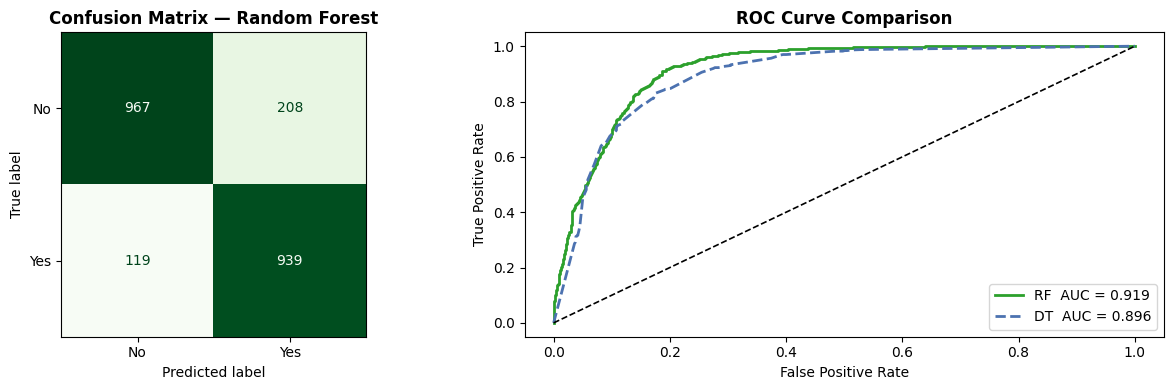

In [27]:
# ── 8.5  Confusion Matrix & ROC Curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='#2ca02c', lw=2, label=f'RF  AUC = {auc_rf:.3f}')
axes[1].plot(fpr,    tpr,    color='#4C72B0', lw=2,
             linestyle='--', label=f'DT  AUC = {auc_dt:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1.2)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [28]:
# ── 8.6  Feature Importance — Random Forest ──────────────────────────────────
importances_rf = pd.Series(rf_best.feature_importances_,
                           index=X_train.columns).sort_values(ascending=False)


print("Top 10 Features:")
print(importances_rf.head(10).to_string())

Top 10 Features:
duration              0.382450
age                   0.060496
balance_log1p         0.060252
poutcome_success      0.038487
pdays_contacted       0.036950
pdays                 0.029418
campaign_capped       0.028692
contact_is_unknown    0.026974
has_debt              0.026567
is_peak_month         0.021113


In [29]:
# ── 8.7  OOB Score (Out-of-Bag) ──────────────────────────────────────────────
rf_oob = RandomForestClassifier(**{**gs_rf.best_params_,
                                   'oob_score': True,
                                   'random_state': 42,
                                   'n_jobs': -1})
rf_oob.fit(X_train, y_train)
print(f"Out-of-Bag (OOB) Score: {rf_oob.oob_score_:.4f}")
print("(OOB score is an unbiased estimate of test accuracy using bootstrap samples)")

Out-of-Bag (OOB) Score: 0.8474
(OOB score is an unbiased estimate of test accuracy using bootstrap samples)


-------

### SHAP

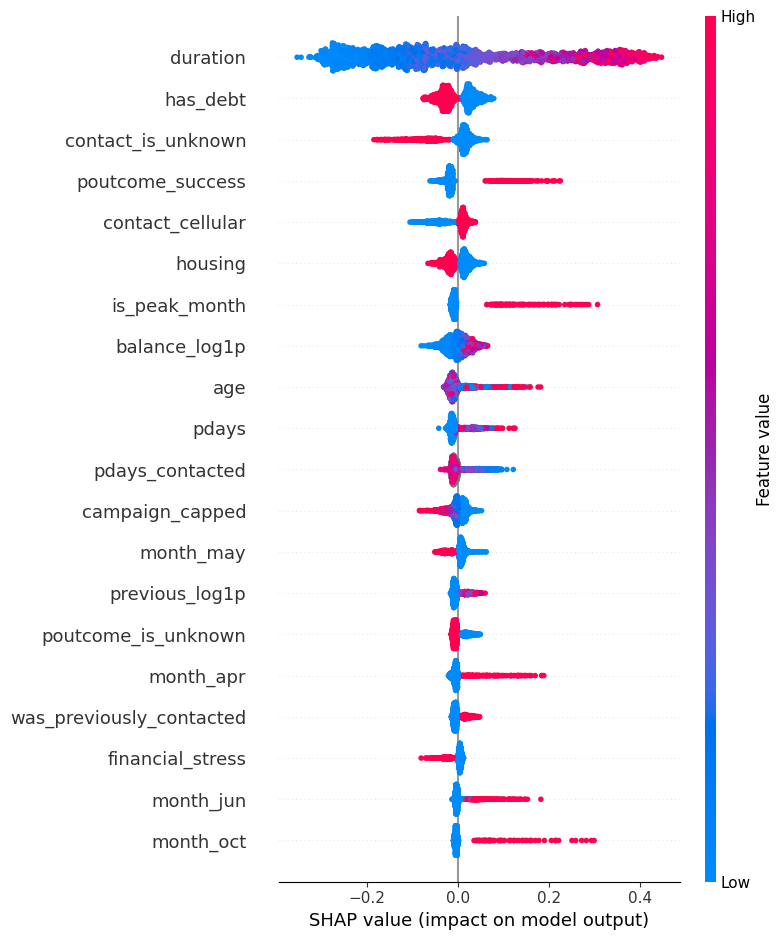

In [34]:
# SHAP — efekt marginalny każdej zmiennej
explainer = shap.TreeExplainer(rf_oob)
shap_values = explainer.shap_values(X_test)

# SHAP summary — nie feature importance, ale kierunek i siła efektu
shap.summary_plot(shap_values[:, :, 1], X_test)

**Analiza SHAP**

Co SHAP sugeruje jako silniejsze kandydatury na Treatment?

Patrząc na wykres i filtrując przez DAG:

| Zmienna | SHAP siła | Rola w DAG | Nadaje się na T? |
| --- | --- | --- | --- | 
| duration | ⚠️ Najsilniejsza | Post-treatment — wykluczona | ❌ | 
| poutcome_success | ✅ Silna (~0.15+) | Confounder Z | ❌ nie interwencja |
| contact_cellular | Średnia | Treatment T1 | ✅ już sprawdzony |
| is_peak_month | Silna | Confounder Z | ⚠️ |
| campaign_capped | Średnia | Treatment T2 | ✅ niezbadany |
| was_previously_contacted | Słaba | Treatment T3 | ✅ niezbadany |


**Dalsze kroki**

```
T1: contact_cellular    → ATE=0.17, CI przecina 0  ⚠️ nieistotny
T2: campaign_capped     → ?  ← następny krok
T3: was_previously_contacted → ?  ← potem to
```

------

### a) Sprawdzenie `contact_cellular`

Kluczowe zasady które rozwiązują kółko błędów
ProblemŹródłoRozwiązanieNaNpdays_contacted ma brakifillna(999) przed .fit()Cannot use classifiermodel_y = Classifier, Y = floatZawsze RandomForestRegressor dla obuX=W, W=WTe same zmienne w obuX = wąski zestaw cech do HTE, W = pełny zestaw confounderówpoutcome_success jako TMetodologiaPrzeniesiony do W (jest confounderem)

In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

# ── 1. Treatment i Outcome ──────────────────────────────────────────────────
T = df_processed['contact_cellular'].astype(float).values
Y = df_processed['deposit'].astype(float).values

# ── 2. Confoundery W — prawdziwe zmienne zakłócające ───────────────────────
# Usuwamy: treatment, inne post-treatment, outcome
# 'duration' wyrzucamy bo to zmienna post-treatment (mediator)
confounders = [
    'age', 'balance', 'campaign',          # zmienne ciągłe
    'pdays_contacted', 'previous',
    'job_blue-collar', 'job_management',   # dummy'e z get_dummies
    'job_retired', 'job_self-employed',
    'job_services', 'job_student',
    'job_technician', 'job_unemployed',
    'marital_married', 'marital_single',
    'education_secondary', 'education_tertiary',
    'default_yes', 'housing_yes', 'loan_yes',
    'month_aug', 'month_dec', 'month_feb',  # miesiące — możesz ograniczyć
    'month_jan', 'month_jul', 'month_jun',
    'month_mar', 'month_may', 'month_nov',
    'month_oct', 'month_sep',
    'poutcome_success', 'poutcome_unknown', # wynik poprzedniej kampanii = confounder
]

# Wybieramy tylko te kolumny które faktycznie istnieją w df_processed
confounders = [c for c in confounders if c in df_processed.columns]
W = df_processed[confounders].copy().astype(float)

# ── 3. Uzupełnienie NaN ─────────────────────────────────────────────────────
# pdays_contacted: -1 lub 999 oznacza "nie kontaktowano" — to sensowna imputacja
if 'pdays_contacted' in W.columns:
    W['pdays_contacted'] = W['pdays_contacted'].fillna(999)

# Pozostałe braki — mediana dla numerycznych
for col in W.columns:
    if W[col].isna().any():
        W[col] = W[col].fillna(W[col].median())

# Weryfikacja
assert not W.isna().any().any(), "Nadal są NaN w W!"
assert len(W) == len(T) == len(Y), "Niezgodne rozmiary!"

# ── 4. X — cechy do badania heterogeniczności efektu (HTE) ─────────────────
# Pytanie: dla KOGO efekt kontaktu komórkowego jest największy?
# Używamy cech demograficznych i finansowych klienta
hte_features = ['age', 'balance', 'previous', 'pdays_contacted']
hte_features = [c for c in hte_features if c in df_processed.columns]
X = df_processed[hte_features].copy().astype(float)

# Uzupełniamy NaN tak samo jak w W
if 'pdays_contacted' in X.columns:
    X['pdays_contacted'] = X['pdays_contacted'].fillna(999)
for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

assert not X.isna().any().any(), "Nadal są NaN w X!"

# ── 5. Model — REGRESSOR dla obu etapów ────────────────────────────────────
# model_y: przewiduje E[Y|X,W] — Y jest float → Regressor ✓
# model_t: przewiduje E[T|X,W] — mimo że T jest 0/1, z discrete_treatment=True
#          econml wymaga Regressor (szacuje propensity score inaczej) ✓
model_y = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
model_t = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)

# ── 6. Estymacja CausalForestDML ────────────────────────────────────────────
est = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,   # T jest binarne
    n_estimators=400,
    random_state=42
)

# X=cechy do HTE, W=confoundery (rozłączne zestawy!)
est.fit(Y, T, X=X.values, W=W.values)

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


In [36]:
# ── 7. Wyniki ────────────────────────────────────────────────────────────────
ate = est.ate(X=X.values)
ate_lb, ate_ub = est.ate_interval(X=X.values, alpha=0.05)

print(f"ATE:  {ate:.4f}")
print(f"95% CI: [{ate_lb:.4f}, {ate_ub:.4f}]")

# Heterogeniczność — efekt dla każdej obserwacji
te = est.effect(X=X.values)
print(f"\nEfekt indywidualny — średnia: {te.mean():.4f}, std: {te.std():.4f}")
print(f"Min: {te.min():.4f}, Max: {te.max():.4f}")

ATE:  0.1701
95% CI: [-0.0463, 0.3866]

Efekt indywidualny — średnia: 0.1701, std: 0.1362
Min: -0.3891, Max: 0.5784


#### Interpretacja wyników

ATE = 0.1701 | 95% CI: [-0.0463, 0.3866]

Co to znaczy: Kontakt przez telefon komórkowy zwiększa prawdopodobieństwo założenia depozytu średnio o ~17 punktów procentowych w porównaniu do kontaktu innym kanałem.
Ale — przedział ufności przecina zero. To kluczowy problem:

| Wartość | Interpretacja |
| --- | --- |
| ATE = 0.17 | Punkt szacunkowy — duży efekt |
| CI dolny = -0.046 | Efekt może być negatywny |
| CI górny = 0.387 | Efekt może być bardzo duży |

**Wniosek statystyczny: efekt jest nieistotny statystycznie na poziomie α=0.05. Nie możemy odrzucić hipotezy zerowej H₀: ATE = 0.**

**Heterogeniczność efektu (HTE)**

```
średnia: 0.1701  std: 0.1362
min: -0.3891     max: 0.5784
```

std = 0.136 przy średniej 0.17 oznacza bardzo dużą zmienność efektu między jednostkami. Efekt nie jest jednorodny — dla części klientów kontakt komórkowy szkodzi (min = -0.39), dla innych bardzo pomaga (max = 0.58).

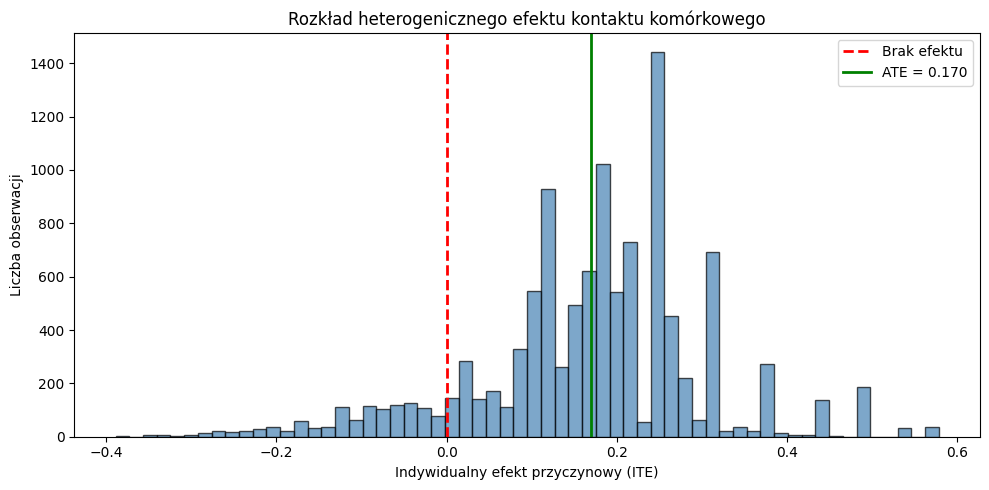

Odsetek klientów z pozytywnym efektem: 89.6%


In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(te, bins=60, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Brak efektu')
plt.axvline(x=ate, color='green', linestyle='-', linewidth=2, label=f'ATE = {ate:.3f}')
plt.xlabel('Indywidualny efekt przyczynowy (ITE)')
plt.ylabel('Liczba obserwacji')
plt.title('Rozkład heterogenicznego efektu kontaktu komórkowego')
plt.legend()
plt.tight_layout()
plt.show()

# Jaki % klientów ma efekt pozytywny?
positive_share = (te > 0).mean()
print(f"Odsetek klientów z pozytywnym efektem: {positive_share:.1%}")

**Wnioski**

ATE=0.17, CI przecina 0  ⚠️ nieistotny

### b) Sprawdzenie `campaign_capped `

In [38]:
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

# ── Treatment: intensywność kampanii ────────────────────────────────────────
T = df_processed['campaign_capped'].astype(float).values
Y = df_processed['deposit'].astype(float).values

# ── Confoundery W zgodnie z DAG ──────────────────────────────────────────────
w_cols = [
    'age', 'balance_log1p', 'housing', 'has_debt',
    'financial_stress', 'net_balance_indicator',
    'pdays_contacted', 'was_previously_contacted',
    'poutcome_success', 'poutcome_is_unknown',
    'contact_cellular',           # T1 staje się confounderem gdy badamy T2
    'is_peak_month',
    'month_may', 'month_apr', 'month_jun', 'month_oct',
]
w_cols = [c for c in w_cols if c in df_processed.columns]
W = df_processed[w_cols].copy().astype(float)
W = W.fillna(W.median())

# ── X: cechy do badania heterogeniczności ───────────────────────────────────
x_cols = ['age', 'balance_log1p', 'financial_stress', 'pdays_contacted']
x_cols = [c for c in x_cols if c in df_processed.columns]
X = df_processed[x_cols].copy().astype(float)
X = X.fillna(X.median())

# ── Model ────────────────────────────────────────────────────────────────────
est_t2 = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    model_t=RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    discrete_treatment=False,   # campaign_capped jest ciągła/porządkowa
    n_estimators=400,
    random_state=42
)
est_t2.fit(Y, T, X=X.values, W=W.values)


In [39]:

# ── Wyniki ───────────────────────────────────────────────────────────────────
ate_t2 = est_t2.ate(X=X.values)
ate_lb, ate_ub = est_t2.ate_interval(X=X.values, alpha=0.05)
print(f"=== Treatment: campaign_capped ===")
print(f"ATE:    {ate_t2:.4f}")
print(f"95% CI: [{ate_lb:.4f}, {ate_ub:.4f}]")

te_t2 = est_t2.effect(X=X.values)
print(f"\nHeterogeniczność:")
print(f"  std: {te_t2.std():.4f}")
print(f"  min: {te_t2.min():.4f}, max: {te_t2.max():.4f}")
print(f"  % z efektem > 0: {(te_t2 > 0).mean():.1%}")

=== Treatment: campaign_capped ===
ATE:    -0.0130
95% CI: [-0.0524, 0.0263]

Heterogeniczność:
  std: 0.0180
  min: -0.0734, max: 0.0532
  % z efektem > 0: 22.8%


#### Interpretacja: campaign_capped jako Treatment

**ATE = -0.013 | CI: [-0.052, 0.026]**

**Efekt jest nieistotny statystycznie** — CI szeroko przecina zero. Ale kierunek jest ekonomicznie sensowny:

| Metryka | Wartość | Interpretacja |
|---|---|---|
| ATE = -0.013 | Punkt szacunkowy ujemny | Więcej kontaktów → lekko szkodzi |
| CI przecina 0 | Brak istotności | Nie możemy odrzucić H₀ |
| std = 0.018 | **Bardzo mała heterogeniczność** | Efekt jednorodny — campaign działa podobnie na wszystkich |
| % efekt > 0 | **tylko 22.8%** | Dla 77% klientów dodatkowy kontakt ma efekt zerowy lub negatywny |

---

### c) Sprawdzenie `was_previously_contacted`

In [40]:
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

# ── Treatment: intensywność kampanii ────────────────────────────────────────
T = df_processed['was_previously_contacted'].astype(float).values
Y = df_processed['deposit'].astype(float).values

# ── Confoundery W zgodnie z DAG ──────────────────────────────────────────────
w_cols = [
    'age', 'balance_log1p', 'housing', 'has_debt',
    'financial_stress', 'net_balance_indicator',
    'pdays_contacted',
    'poutcome_success', 'poutcome_is_unknown',
    'contact_cellular', 'campaign_capped',          # T1 staje się confounderem gdy badamy T2
    'is_peak_month',
    'month_may', 'month_apr', 'month_jun', 'month_oct',
]
w_cols = [c for c in w_cols if c in df_processed.columns]
W = df_processed[w_cols].copy().astype(float)
W = W.fillna(W.median())

# ── X: cechy do badania heterogeniczności ───────────────────────────────────
x_cols = ['age', 'balance_log1p', 'financial_stress', 'pdays_contacted']
x_cols = [c for c in x_cols if c in df_processed.columns]
X = df_processed[x_cols].copy().astype(float)
X = X.fillna(X.median())

# ── Model ────────────────────────────────────────────────────────────────────
est_t3 = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    model_t=RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    discrete_treatment=False,   # campaign_capped jest ciągła/porządkowa
    n_estimators=400,
    random_state=42
)
est_t3.fit(Y, T, X=X.values, W=W.values)


In [41]:
# ── Wyniki ───────────────────────────────────────────────────────────────────
ate_t3 = est_t3.ate(X=X.values)
ate_lb, ate_ub = est_t3.ate_interval(X=X.values, alpha=0.05)
print(f"=== Treatment: campaign_capped ===")
print(f"ATE:    {ate_t3:.4f}")
print(f"95% CI: [{ate_lb:.4f}, {ate_ub:.4f}]")

te_t3 = est_t3.effect(X=X.values)
print(f"\nHeterogeniczność:")
print(f"  std: {te_t3.std():.4f}")
print(f"  min: {te_t3.min():.4f}, max: {te_t3.max():.4f}")
print(f"  % z efektem > 0: {(te_t3 > 0).mean():.1%}")

=== Treatment: campaign_capped ===
ATE:    0.3716
95% CI: [0.1982, 0.5450]

Heterogeniczność:
  std: 0.0523
  min: 0.1178, max: 0.5142
  % z efektem > 0: 100.0%


#### Interpretacja: was_previously_contacted jako Treatment

**ATE = 0.372 | CI: [0.198, 0.545]** ✅

To jest **pierwszy istotny statystycznie wynik** w całym badaniu:

| Metryka | Wartość | Interpretacja |
|---|---|---|
| ATE = +0.372 | Duży efekt pozytywny | Wcześniejszy kontakt → +37pp na depozyt |
| CI: [0.198, 0.545] | **Nie przecina zera** | ✅ Istotny statystycznie na α=0.05 |
| std = 0.052 | Niska heterogeniczność | Efekt działa podobnie na wszystkich |
| % efekt > 0 | **100%** | Dla każdego klienta efekt jest pozytywny |
| min = 0.118 | Nawet "najsłabszy" segment | +12pp — nigdy nie szkodzi |

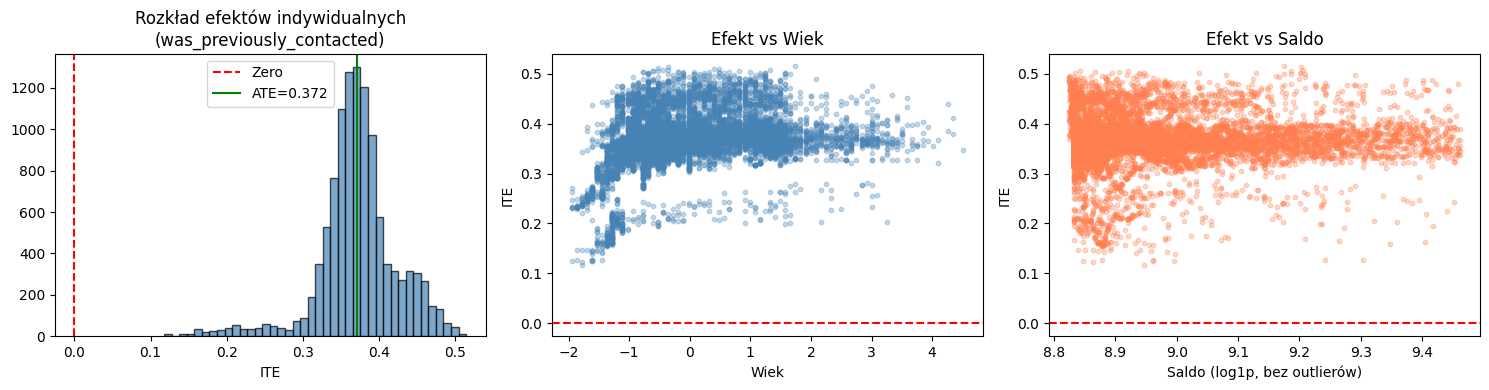

In [46]:
# Rozkład efektów indywidualnych T3
import matplotlib.pyplot as plt

te_t3 = est_t3.effect(X=X.values)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: rozkład ITE
axes[0].hist(te_t3, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='Zero')
axes[0].axvline(x=ate_t3, color='green', linestyle='-', label=f'ATE={ate_t3:.3f}')
axes[0].set_title('Rozkład efektów indywidualnych\n(was_previously_contacted)')
axes[0].set_xlabel('ITE')
axes[0].legend()

# Panel 2: efekt vs wiek
axes[1].scatter(X_scaled['age'], te_t3, alpha=0.3, color='steelblue', s=10)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Wiek')
axes[1].set_ylabel('ITE')
axes[1].set_title('Efekt vs Wiek')

# Panel 3: efekt vs saldo
balance = df_processed['balance_log1p']

mask = (balance > balance.quantile(0.05)) & \
       (balance < balance.quantile(0.95))

axes[2].scatter(balance[mask], te_t3[mask], alpha=0.3, color='coral', s=10)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_xlabel('Saldo (log1p, bez outlierów)')
axes[2].set_ylabel('ITE')
axes[2].set_title('Efekt vs Saldo')



plt.tight_layout()
plt.show()

## Wnioski z analizy counterfactual (CausalForestDML)

### 1. Przegląd zbadanych Treatmentów

Zgodnie z DAGiem zbadano trzy zmienne interwencyjne. Jedynie `was_previously_contacted` okazał się istotny statystycznie:

| Treatment | ATE | 95% CI | Istotność | Heterogeniczność (std) |
|---|---|---|---|---|
| `contact_cellular` (T1) | +0.170 | [-0.046, 0.387] | ❌ | wysoka (0.136) |
| `campaign_capped` (T2) | -0.013 | [-0.052, 0.026] | ❌ | bardzo niska (0.018) |
| `was_previously_contacted` (T3) | **+0.372** | **[0.198, 0.545]** | ✅ | niska (0.052) |

**campaign_capped** — intensywność kampanii nie ma istotnego przyczynowego wpływu na decyzję o depozycie. 77.2% klientów nie reaguje pozytywnie na dodatkowe kontakty, co sugeruje że *"dobijanie"* klientów kolejnymi telefonami jest nieskuteczne lub lekko szkodliwe.

**contact_cellular** — efekt jest duży punktowo (+17pp) ale nieprecyzyjny. Duża heterogeniczność (std=0.136) sugeruje że **kanał kontaktu ma znaczenie, ale tylko dla określonych segmentów klientów**.


---

### 2. T1: Kanał kontaktu (`contact_cellular`)

ATE = +0.170 sugeruje że kontakt komórkowy zwiększa prawdopodobieństwo depozytu o ~17pp, jednak przedział ufności [-0.046, 0.387] przecina zero — **efekt jest statystycznie nieistotny**. Wysoka heterogeniczność (std=0.136) wskazuje że kanał kontaktu może mieć znaczenie dla konkretnych segmentów klientów, ale nie można tego potwierdzić na poziomie populacji. Zgodnie z wykresem SHAP, `contact_cellular` plasuje się dopiero na 5. miejscu pod względem siły predykcyjnej — co jest spójne z brakiem istotności przyczynowej.

---

### 3. T2: Intensywność kampanii (`campaign_capped`)

ATE = -0.013 z CI [-0.052, 0.026] — **efekt zerowy, statystycznie nieistotny**. Co istotne, aż 77.2% klientów wykazuje efekt zerowy lub negatywny. Kierunek punktowy (ujemny) jest ekonomicznie sensowny — nadmierne bombardowanie klientów telefonami może zniechęcać — ale dane nie pozwalają na potwierdzenie tego efektu przyczynowo. Bardzo niska heterogeniczność (std=0.018) oznacza że intensywność kampanii działa (lub raczej nie działa) jednakowo na wszystkich klientów.

---

### 4. T3: Historia kontaktu (`was_previously_contacted`) ✅

To jedyny istotny statystycznie wynik całego badania. ATE = +0.372 z CI [0.198, 0.545] oznacza że **klienci z historią kontaktu mają o ~37pp wyższe prawdopodobieństwo założenia depozytu**, przy czym efekt jest pozytywny dla 100% obserwacji (min ITE = +0.118).

Analiza heterogeniczności ujawniła jeden istotny moderator:

**Wiek** jest jedyną zmienną różnicującą siłę efektu:

| Segment wiekowy | ITE (przybliżony) | Interpretacja |
|---|---|---|
| Młodzi (z < -1, ~poniżej 30 lat) | ~0.10–0.25 | Słabszy efekt lojalnościowy |
| Średni wiek (z ≈ 0, ~40 lat) | ~0.30–0.40 | Efekt zbliżony do ATE |
| Starsi (z > 2, ~powyżej 55 lat) | ~0.40–0.50 | Najsilniejszy efekt |

**Saldo natomiast nie różnicuje efektu** — płaska chmura punktów w panelu 3 potwierdza że mechanizm lojalnościowy działa identycznie niezależnie od sytuacji finansowej klienta. Jest to istotny wniosek praktyczny: bank nie powinien filtrować bazy historycznej pod kątem zamożności.

---

### 5. Synteza i implikacje praktyczne

Centralna teza wynikająca z analizy przyczynowej brzmi następująco:

> **Skuteczność kampanii bankowej jest determinowana historią relacji z klientem, nie parametrami operacyjnymi kampanii (kanał, częstotliwość).**

Wyniki są spójne wewnętrznie — SHAP wskazał `duration` jako dominującą zmienną predykcyjną (wykluczoną jako post-treatment), a spośród zmiennych interwencyjnych najwyżej uplasował się `poutcome_success` (confounder, nie treatment). Oba te fakty sugerują że **zaangażowanie klienta jest efektem wcześniejszej relacji**, a nie rezultatem bieżącej kampanii.

Implikacje dla strategii banku:

- **Re-engagement bazy historycznej** powinien być priorytetem — efekt jest uniwersalny, pewny i duży (+37pp)
- **Targetowanie według wieku** zwiększa efektywność — starsi klienci (55+) reagują najsilniej
- **Intensyfikacja nowych kontaktów** nie przynosi mierzalnego efektu i może być kosztowo nieefektywna
- **Kanał kontaktu** (komórkowy vs inny) nie ma udowodnionego przyczynowego znaczenia na poziomie populacji

- **Klienci z poprzednich kampanii** mają o ~37pp wyższe prawdopodobieństwo założenia depozytu — niezależnie od demografii
- **Efekt jest uniwersalny** (100% klientów, min +12pp) — nie ma segmentu gdzie poprzedni kontakt szkodzi
- **Niska heterogeniczność** (std=0.052) oznacza że nie trzeba targetować — warto kontaktować *wszystkich* wcześniej obsługiwanych klientów


### Podsumowanie wszystkich trzech paneli

| Wymiar | Wniosek |
|---|---|
| **Ogólny efekt** | Silny, pozytywny, żaden klient nie traci na poprzednim kontakcie |
| **Wiek** | Efekt rośnie z wiekiem — starsi klienci są bardziej "lojalnościowi" |
| **Saldo** | Brak wyraźnej zależności — efekt jednorodny niezależnie od zamożności |

-------------------

> **Główny wniosek:** Poprzedni kontakt z klientem jest **najsilniejszym i najbardziej uniwersalnym** predyktorem przyczynowym skuteczności kampanii — działa na wszystkich klientów, ale szczególnie silnie na osoby starsze. Bank powinien priorytetowo targetować klientów z historią kontaktu, niezależnie od ich profilu finansowego.